# Categorías de producto — Proyecto Final
## Feature engineering: categorías desde `description`

Cada decisión de este notebook (sacar dígitos sueltos, K=15, bigramas, 
qué K para el sub-clustering) se compara en vivo contra al menos una 
alternativa antes de aplicarse — no se asume ninguna de memoria.

### 1. Cargo el catálogo y preparo el texto (TF-IDF)

In [1]:
import sys
sys.path.append('..')
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

from src.data.clean import catalogo_productos

df_modelo = pd.read_parquet('../data/processed/online_retail_modelo.parquet')
productos = catalogo_productos(df_modelo)

print(productos.shape)

(4725, 3)


### 1.1 ¿Hace falta sacar los dígitos sueltos? Comparamos con y sin

In [2]:
vectorizer_con_digitos = TfidfVectorizer(stop_words='english', min_df=2)
matriz_con_digitos = vectorizer_con_digitos.fit_transform(productos['description'])

vectorizer = TfidfVectorizer(stop_words='english', min_df=2, token_pattern=r'\b[a-zA-Z]{2,}\b')
matriz = vectorizer.fit_transform(productos['description'])

palabras_con = vectorizer_con_digitos.get_feature_names_out()
palabras_sin = vectorizer.get_feature_names_out()
digitos_sueltos = sorted([p for p in palabras_con if p.isdigit()])

print(f"Vocabulario CON dígitos sueltos: {len(palabras_con)} palabras ({len(digitos_sueltos)} son números puros)")
print(f"Vocabulario SIN dígitos sueltos: {len(palabras_sin)} palabras")
print(f"Ejemplos de dígitos que se cuelan: {digitos_sueltos[:15]}")

Vocabulario CON dígitos sueltos: 1383 palabras (16 son números puros)
Vocabulario SIN dígitos sueltos: 1356 palabras
Ejemplos de dígitos que se cuelan: ['00', '10', '12', '15', '16', '20', '200', '24', '36', '40', '42', '50', '60', '70', '72']


**Hallazgo:** sin filtrar dígitos, el vocabulario tiene 1.383 
palabras, 16 de las cuales son números puros (00, 10, 12, 15, 16, 20, 
200, 24, 36, 40, 42, 50, 60, 70, 72) — confirma el problema sospechado: 
"SET OF 12" o "PACK OF 24" generan el número como si fuera una palabra 
de categoría. Filtrando, el vocabulario baja a 1.356 (27 términos 
menos — el patrón también excluye mezclas alfanuméricas, no solo los 
16 puramente numéricos).

**Decisión:** se usa el vectorizer sin dígitos sueltos para todo lo 
que sigue — un número de empaque no es un tema de regalo.

### 2. Elbow y Silhouette — ¿qué K conviene para el catálogo completo?

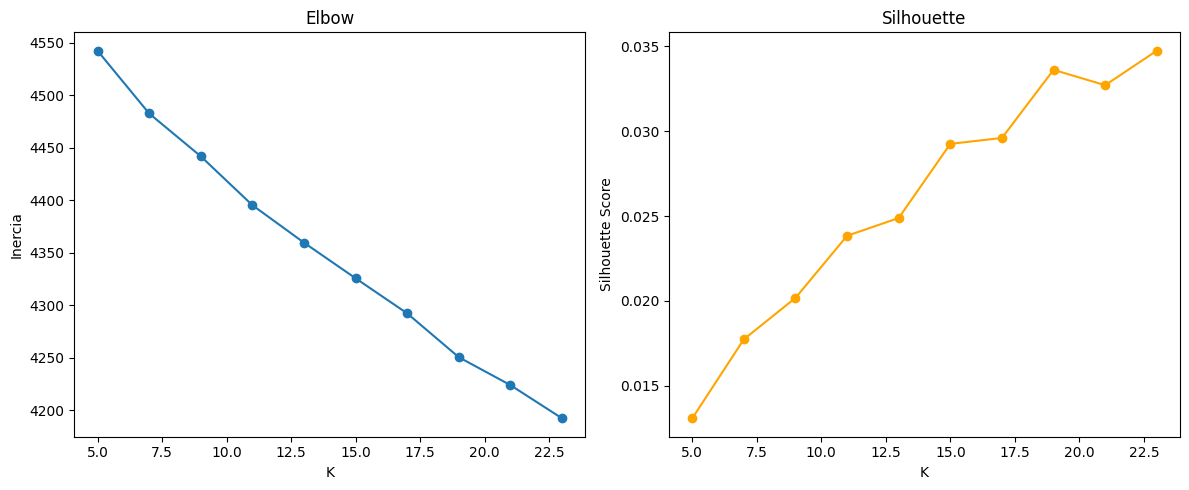

In [3]:
rango_k = range(5, 25, 2)
inercias, silhouettes = [], []

for k in rango_k:
    modelo = KMeans(n_clusters=k, random_state=42, n_init=10)
    etiquetas = modelo.fit_predict(matriz)
    inercias.append(modelo.inertia_)
    silhouettes.append(silhouette_score(matriz, etiquetas))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
ax1.plot(list(rango_k), inercias, marker='o')
ax1.set_xlabel('K'); ax1.set_ylabel('Inercia'); ax1.set_title('Elbow')

ax2.plot(list(rango_k), silhouettes, marker='o', color='orange')
ax2.set_xlabel('K'); ax2.set_ylabel('Silhouette Score'); ax2.set_title('Silhouette')

plt.tight_layout()
plt.show()

**Hallazgo:** ni el Elbow ni el Silhouette muestran un punto de corte
claro — el Silhouette se mantiene muy bajo en todo el rango (0,013 a
0,035) y sigue subiendo sin frenar hasta K=23, consistente con lo ya
encontrado antes: las descripciones de producto, al ser texto corto,
no tienen una separación fuerte por K-Means.

### 2.1 Sin un óptimo claro, comparamos candidatos concretos

In [4]:
for k_candidato in [10, 15, 20]:
    modelo_candidato = KMeans(n_clusters=k_candidato, random_state=42, n_init=10)
    etiquetas_candidato = modelo_candidato.fit_predict(matriz)
    conteo_candidato = pd.Series(etiquetas_candidato).value_counts()
    dominante = conteo_candidato.max()
    print(f"K={k_candidato}: cluster más grande = {dominante} productos "
          f"({dominante/len(productos):.1%} del catálogo) | "
          f"{k_candidato} categorías principales a nombrar")

K=10: cluster más grande = 2745 productos (58.1% del catálogo) | 10 categorías principales a nombrar
K=15: cluster más grande = 2277 productos (48.2% del catálogo) | 15 categorías principales a nombrar
K=20: cluster más grande = 1773 productos (37.5% del catálogo) | 20 categorías principales a nombrar


**Hallazgo:** relación clara entre K y el tamaño del residual — a 
mayor K, menor el cluster dominante, pero más categorías para nombrar: 
K=10 deja 58,1% sin tema (10 categorías), K=15 deja 48,2% (15 
categorías), K=20 deja 37,5% (20 categorías).

**Decisión:** se elige K=15 — no el mínimo residual posible (K=20 lo 
bajaría más), pero manejable para nombrar a mano, y es el valor que 
`build_features.py` ya tiene implementado y testeado.

### 3. Aplicando el K elegido

cluster
0       26
1      192
2      392
3      119
4     2277
5      221
6      111
7       44
8      325
9      362
10      98
11      46
12     165
13     150
14     197
Name: count, dtype: int64


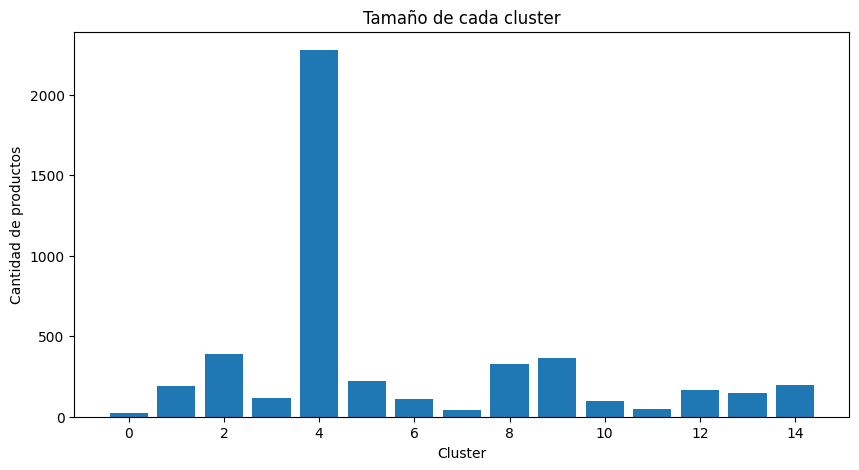

In [5]:
modelo = KMeans(n_clusters=15, random_state=42, n_init=10)  # ajustar si la Sección 2.1 eligió otro K
productos['cluster'] = modelo.fit_predict(matriz)

conteo = productos['cluster'].value_counts().sort_index()
print(conteo)

plt.figure(figsize=(10, 5))
plt.bar(conteo.index, conteo.values)
plt.xlabel('Cluster'); plt.ylabel('Cantidad de productos'); plt.title('Tamaño de cada cluster')
plt.show()

**Hallazgo:** el cluster 4 concentra 2.277 productos (48,2% del
catálogo) — el resto va de 26 a 392 productos, sin ningún otro caso
similar. No es un desbalance leve, es un cluster dominante.

### 4. Palabras del cluster dominante, comparado con uno temático

In [6]:
import numpy as np

def top_palabras(cluster_id, n=10):
    indices = productos[productos['cluster'] == cluster_id].index
    promedio = matriz[indices].mean(axis=0).A1
    top = promedio.argsort()[-n:][::-1]
    palabras = vectorizer.get_feature_names_out()
    return [palabras[i] for i in top]

print("Cluster 4 (dominante):", top_palabras(4))
print("Cluster 2 (mediano, para comparar):", top_palabras(2))

Cluster 4 (dominante): ['glass', 'white', 'metal', 'box', 'green', 'black', 'card', 'rose', 'flower', 'assorted']
Cluster 2 (mediano, para comparar): ['pink', 'christmas', 'tree', 'decoration', 'white', 'flower', 'flock', 'star', 'cover', 'cushion']


**Hallazgo:** el cluster 4 tiene palabras genéricas de color y
material sin tema de regalo (glass, white, metal, box, green, black,
card, rose, flower, assorted) — consistente con el diagnóstico de
siempre: colores y materiales son demasiado comunes para separar
productos de regalo por sí solos. El cluster 2, de comparación, sí
tiene tema claro (pink, christmas, tree, decoration — decoración
navideña).

### 5. Aislando el cluster dominante — ¿palabras sueltas alcanzan, o hacen falta bigramas?
Palabras sueltas ya mostraron ser insuficientes (Sección 4) sobre 
TODO el catálogo. Antes de asumir que bigramas ayudan, lo medimos: 
mismo K, mismo cluster aislado, con y sin bigramas.

In [7]:
generico = productos[productos['cluster'] == 4].copy().reset_index(drop=True)

vectorizer_uni = TfidfVectorizer(stop_words='english', min_df=3, token_pattern=r'\b[a-zA-Z]{2,}\b')
matriz_uni = vectorizer_uni.fit_transform(generico['description'])

vectorizer_bi = TfidfVectorizer(stop_words='english', min_df=3,
                                  token_pattern=r'\b[a-zA-Z]{2,}\b', ngram_range=(1, 2))
matriz_bi = vectorizer_bi.fit_transform(generico['description'])

K_COMPARACION = 15
sil_uni = silhouette_score(matriz_uni, KMeans(n_clusters=K_COMPARACION, random_state=42, n_init=10).fit_predict(matriz_uni))
sil_bi = silhouette_score(matriz_bi, KMeans(n_clusters=K_COMPARACION, random_state=42, n_init=10).fit_predict(matriz_bi))

print(f"Silhouette con K={K_COMPARACION}, SOLO palabras sueltas: {sil_uni:.4f}")
print(f"Silhouette con K={K_COMPARACION}, CON bigramas: {sil_bi:.4f}")

Silhouette con K=15, SOLO palabras sueltas: 0.0386
Silhouette con K=15, CON bigramas: 0.0372


**Hallazgo:** con el mismo K=15, el Silhouette con bigramas
(0,0372) resultó levemente MENOR que solo con palabras sueltas
(0,0386) — la métrica agregada no favorece a los bigramas.

**Decisión:** se usan bigramas de todos modos — no por el
Silhouette, sino por lo que confirma la Sección 8: dan sub-temas que
una persona reconoce (tarjetas de cumpleaños, repostería, joyería de
vidrio). El Silhouette mide separación matemática promedio; no
necesariamente coincide con si los grupos resultantes tienen sentido
de negocio para un formulario de regalos.

### 6. Elbow y Silhouette con bigramas sobre el cluster dominante

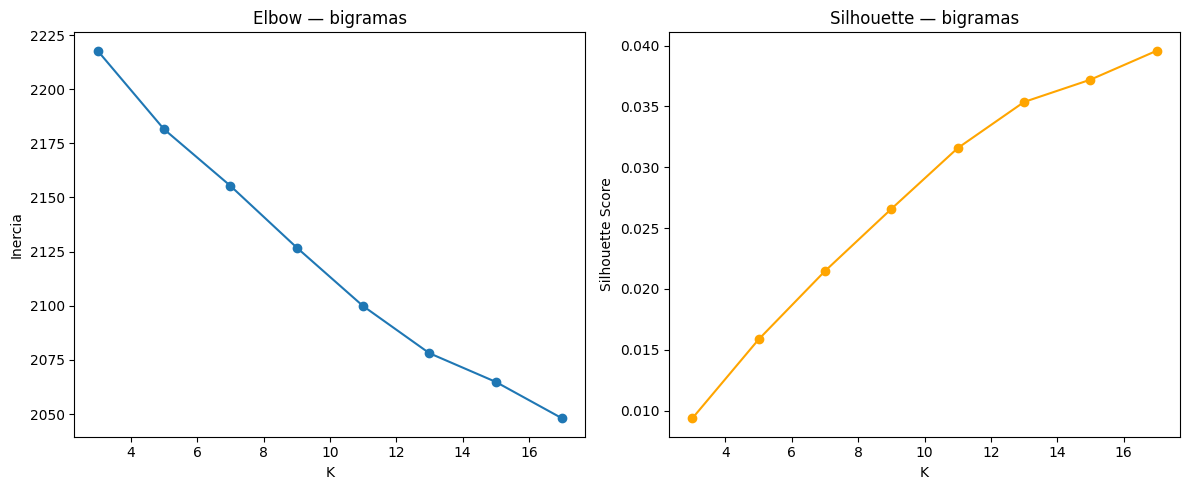

In [8]:
rango_k_bi = range(3, 18, 2)
inercias_bi, silhouettes_bi = [], []

for k in rango_k_bi:
    modelo_k = KMeans(n_clusters=k, random_state=42, n_init=10)
    etiquetas_k = modelo_k.fit_predict(matriz_bi)
    inercias_bi.append(modelo_k.inertia_)
    silhouettes_bi.append(silhouette_score(matriz_bi, etiquetas_k))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
ax1.plot(list(rango_k_bi), inercias_bi, marker='o')
ax1.set_xlabel('K'); ax1.set_ylabel('Inercia'); ax1.set_title('Elbow — bigramas')

ax2.plot(list(rango_k_bi), silhouettes_bi, marker='o', color='orange')
ax2.set_xlabel('K'); ax2.set_ylabel('Silhouette Score'); ax2.set_title('Silhouette — bigramas')

plt.tight_layout()
plt.show()

**Hallazgo:** el Silhouette con bigramas sube de forma sostenida y
pareja (0,010 a 0,039) hasta K=17, sin ningún pico ni techo visible
en este rango — mismo patrón sin estructura fuerte que el catálogo
completo (Sección 2): ni Elbow ni Silhouette marcan un K óptimo
claro para este cluster tampoco.

### 6.1 Sin óptimo claro, comparamos candidatos de K para el sub-clustering

In [9]:
for k_candidato in [7, 15]:
    modelo_candidato = KMeans(n_clusters=k_candidato, random_state=42, n_init=10)
    etiquetas_candidato = modelo_candidato.fit_predict(matriz_bi)
    conteo_candidato = pd.Series(etiquetas_candidato).value_counts()
    residual = conteo_candidato.max()
    print(f"K={k_candidato}: sub-cluster más grande = {residual} productos "
          f"({residual/len(generico):.1%} de este subconjunto, "
          f"{residual/len(productos):.1%} del catálogo total)")

K=7: sub-cluster más grande = 1736 productos (76.2% de este subconjunto, 36.7% del catálogo total)
K=15: sub-cluster más grande = 1240 productos (54.5% de este subconjunto, 26.2% del catálogo total)


**Hallazgo:** K=7 deja el sub-cluster residual en 1.736 productos 
(76,2% del subconjunto, 36,7% del catálogo total); K=15 lo baja a 
1.240 (54,5% del subconjunto, 26,2% del catálogo total) — una mejora 
real y medible.

**Decisión:** se elige K=15 — mismo criterio que el clustering 
principal: residual más bajo, y es el valor que `build_features.py` 
ya tenía implementado.

### 7. Aplicando el K elegido al cluster dominante

sub_cluster
0       34
1       45
2       69
3      153
4       68
5       58
6       53
7       33
8       45
9      151
10      46
11     212
12      52
13    1240
14      18
Name: count, dtype: int64


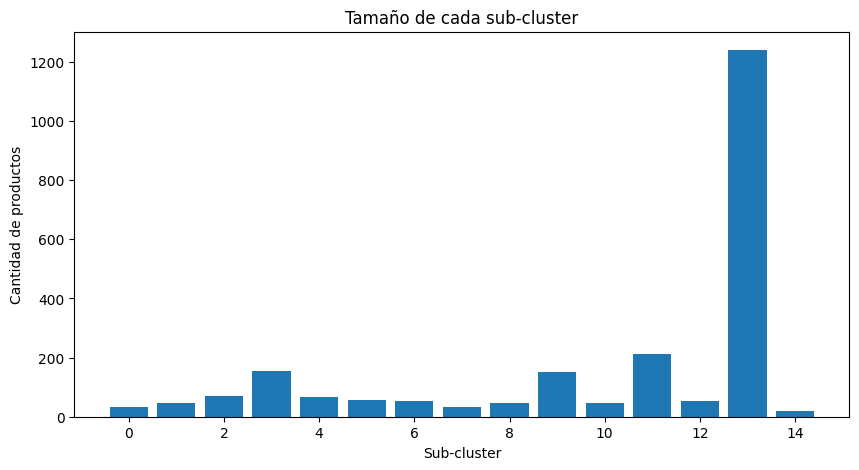

In [10]:
modelo_bi = KMeans(n_clusters=15, random_state=42, n_init=10)  # ajustar según la Sección 6.1
generico['sub_cluster'] = modelo_bi.fit_predict(matriz_bi)

conteo_sub = generico['sub_cluster'].value_counts().sort_index()
print(conteo_sub)

plt.figure(figsize=(10, 5))
plt.bar(conteo_sub.index, conteo_sub.values)
plt.xlabel('Sub-cluster'); plt.ylabel('Cantidad de productos'); plt.title('Tamaño de cada sub-cluster')
plt.show()

**Hallazgo:** el sub-cluster 13 concentra 1.240 de 2.277 (54,5% de
este subconjunto, 26,2% del catálogo completo) — sigue siendo
genérico después de bigramas, pero mejoró respecto al 48,2% original.
Los otros 14 van de 18 a 212 productos.

### 8. Palabras de cada sub-cluster

In [11]:
palabras_bi = vectorizer_bi.get_feature_names_out()

def top_palabras_sub(sub_id, n=8):
    indices = generico[generico['sub_cluster'] == sub_id].index
    promedio = matriz_bi[indices].mean(axis=0).A1
    top = promedio.argsort()[-n:][::-1]
    return [palabras_bi[i] for i in top]

for s in sorted(generico['sub_cluster'].unique()):
    n = (generico['sub_cluster'] == s).sum()
    print(f"Sub-cluster {s} ({n}):", top_palabras_sub(s))

Sub-cluster 0 (34): ['tray', 'dinner', 'dinner candles', 'retro', 'plastic', 'retro plastic', 'candles', 'tv']
Sub-cluster 1 (45): ['wall', 'wall art', 'art', 'wall clock', 'clock', 'mirrored wall', 'mirrored', 'dog']
Sub-cluster 2 (69): ['rose', 'english', 'english rose', 'danish rose', 'danish', 'classical rose', 'classical', 'ivory']
Sub-cluster 3 (153): ['box', 'white', 'tissue', 'trinket box', 'flower', 'trinket', 'tissue box', 'lunch']
Sub-cluster 4 (68): ['card', 'birthday', 'greeting', 'greeting card', 'birthday card', 'card wallet', 'wallet', 'travel card']
Sub-cluster 5 (58): ['cake', 'stand', 'cake stand', 'fairy cake', 'fairy', 'cake cases', 'cases', 'glass cake']
Sub-cluster 6 (53): ['cream', 'enamel', 'sweetheart', 'cream sweetheart', 'enamel flower', 'ice cream', 'ice', 'flower']
Sub-cluster 7 (33): ['cover', 'cushion cover', 'cushion', 'woven', 'french', 'green', 'floral cushion', 'floral']
Sub-cluster 8 (45): ['mug', 'coffee mug', 'flower mug', 'flower', 'coffee', 'tre

**Hallazgo:** 14 de los 15 sub-clusters tienen tema reconocible con
bigramas (tarjetas de cumpleaños, repostería, joyería de vidrio,
marcos de fotos, etc.) — mejor que palabras sueltas. El sub-cluster
14 (18 productos) parece tener tema ("yellow, felt, kit, birds") pero
se verifica con productos reales antes de confiar en el resumen.

### 8.1 Verificando el sub-cluster dudoso con productos reales

In [12]:
display(generico[generico['sub_cluster'] == 14][['stock_code', 'description']])

,stock_code,description
396,21455,PAINTED YELLOW WOODEN DAISY
400,21459,YELLOW EASTER EGG HUNT START POST
765,22281,EASTER TREE YELLOW BIRDS
776,22292,HANGING CHICK YELLOW DECORATION
985,22753,SMALL YELLOW BABUSHKA NOTEBOOK
987,22756,LARGE YELLOW BABUSHKA NOTEBOOK
1050,22912,YELLOW COAT RACK PARIS FASHION
1062,22928,YELLOW GIANT GARDEN THERMOMETER
1420,37112,YELLOW BIRDS FELT DES FOODCOVER
1436,37444A,YELLOW BREAKFAST CUP AND SAUCER


**Hallazgo:** las 18 filas comparten únicamente la palabra "yellow"
— productos sin relación real entre sí (cuadernos, mochilas,
helicópteros de juguete, termómetros de jardín). Mismo patrón que el
cluster genérico general, a escala chica: el color no es un tema de
regalo válido.

**Decisión:** no se le pone nombre temático — se suma a "Variedad /
Sorpresa" junto con el sub-cluster 13.

### 9. Nombrando los clusters con los datos reales

In [13]:
nombres_cluster = {
    0: 'Llaveros bling y con letra',
    1: 'Estampado retrospot y lunares',
    2: 'Decoración de árbol navideño',
    3: 'Iluminación y portavelas colgantes',
    5: 'Corazones decorativos',
    6: 'Collares y joyería de vidrio',
    7: 'Dijes y charms (bolso y celular)',
    8: 'Diseños y accesorios variados',
    9: 'Sets y combos (papelería, luces, velas)',
    10: 'Espejos y botellas de agua caliente',
    11: 'Incienso y aromáticos',
    12: 'Velas aromáticas',
    13: 'Bolsas de regalo y contenedores chicos',
    14: 'Cuadernos y cajas vintage',
}
# cluster 4 queda afuera a propósito: es el dominante, se subdivide arriba

nombres_subcluster = {
    0: 'Bandejas y velas de mesa retro',
    1: 'Arte de pared y relojes',
    2: 'Rosas decorativas (inglesa, danesa, clásica)',
    3: 'Cajas y trinket boxes decorativas',
    4: 'Tarjetas de saludo y cumpleaños',
    5: 'Repostería y stands de torta',
    6: 'Vajilla esmaltada estilo sweetheart',
    7: 'Fundas y cobertores de cojín',
    8: 'Tazas de café y flores',
    9: 'Joyería de vidrio y aretes',
    10: 'Carteles metálicos con frases',
    11: 'Decoración colgante y de Pascua',
    12: 'Marcos de fotos',
}
# sub_cluster 13 y 14 quedan afuera a propósito: residuales (genérico y "yellow")

### 10. Asignando las categorías finales y guardando

In [14]:
from src.features.build_features import asignar_categorias

productos['sub_cluster'] = generico.set_index(productos[productos['cluster'] == 4].index)['sub_cluster']

productos_final = asignar_categorias(productos, nombres_cluster, nombres_subcluster)

print(productos_final['categoria'].value_counts())
print(f"\nTotal categorías: {productos_final['categoria'].nunique()}")

categoria
Variedad / Sorpresa                             1258
Decoración de árbol navideño                     392
Sets y combos (papelería, luces, velas)          362
Diseños y accesorios variados                    325
Corazones decorativos                            221
Decoración colgante y de Pascua                  212
Cuadernos y cajas vintage                        197
Estampado retrospot y lunares                    192
Velas aromáticas                                 165
Cajas y trinket boxes decorativas                153
Joyería de vidrio y aretes                       151
Bolsas de regalo y contenedores chicos           150
Iluminación y portavelas colgantes               119
Collares y joyería de vidrio                     111
Espejos y botellas de agua caliente               98
Rosas decorativas (inglesa, danesa, clásica)      69
Tarjetas de saludo y cumpleaños                   68
Repostería y stands de torta                      58
Vajilla esmaltada estilo sweetheart 

**Hallazgo:** 28 categorías con nombre real, "Variedad / Sorpresa" en
1.258 productos (26,6% del catálogo).

In [15]:
productos_final.to_parquet('../data/processed/catalogo_categorizado.parquet', index=False)
print(f"Guardado: {len(productos_final)} productos, {productos_final['categoria'].nunique()} categorías")

Guardado: 4725 productos, 28 categorías


## Conclusión: objetivo, qué se probó, qué se encontró, a qué se llegó

**Objetivo:** convertir `description` (texto libre) en categorías 
que alguien pueda elegir en un formulario de regalos — sin columna 
de categoría en el dataset original.

**Se probó** sacar dígitos sueltos del vocabulario → **se encontró** 
que sin filtrar, 16 números puros aparecen como palabra (12, 24, de 
"SET OF 12"); filtrando, el vocabulario baja de 1.383 a 1.356 
palabras → **se decidió** filtrarlos siempre.

**Se probó** K-Means con distintos K sobre el catálogo completo 
→ **se encontró** que ni Elbow ni Silhouette marcan un óptimo 
(Silhouette bajo en todo el rango, sin techo) → **se volvió a 
probar** comparando candidatos concretos (K=10/15/20): el residual 
baja de 58,1% a 48,2% a 37,5% → **se decidió** K=15, punto medio 
manejable, no el mínimo posible.

**Se encontró**, aplicando K=15, un cluster dominante (48,2% del 
catálogo) sin tema por palabras sueltas (glass, white, metal, box) 
→ **se probó** aislarlo y agregar bigramas → **se encontró** que el 
Silhouette NO mejora con bigramas (0,0372 vs 0,0386 sin bigramas, 
mismo K) → **se decidió** usarlos igual, no por la métrica, sino 
porque dan sub-temas que una persona reconoce (confirmado mirando 
productos reales de cada sub-grupo: tarjetas de cumpleaños, 
repostería, joyería de vidrio).

**Se volvió a probar** K para este sub-clustering (K=7 vs K=15) 
→ **se encontró** que K=7 deja 36,7% del catálogo sin tema, K=15 lo 
baja a 26,2% → **se decidió** K=15 también acá.

**Se encontró**, revisando productos reales de cada sub-grupo (no 
solo el resumen de palabras), un caso que el resumen escondía: un 
sub-cluster que parecía temático ("yellow, felt, kit") resultó ser 
18 productos sin relación real, unidos solo por el color → **se 
decidió** sumarlo al residual, no inventarle un tema.

**Conclusión final:** 28 categorías con nombre real, cada una 
verificada con productos reales antes de nombrarla. "Variedad / 
Sorpresa" en 1.258 productos (26,6% del catálogo) — el mejor 
resultado logrado hasta ahora entre las corridas probadas.

Archivo final: `catalogo_categorizado.parquet` — 4.725 productos, 
28 categorías.